# 04 — Visualization
**Healthcare Operations Analytics**

Charts referenced in the executive report and README, saved to `../visuals/`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

features = pd.read_csv('../data/cleaned/admissions_features.csv')
print(features.shape)

(46500, 22)


## Monthly admission volume (seasonality check)

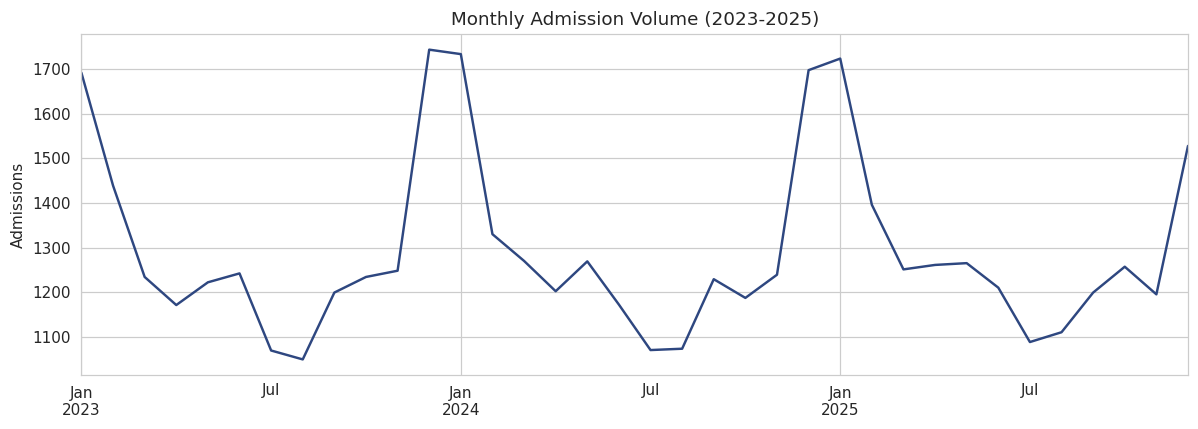

In [2]:
admissions_raw = pd.read_csv('../data/cleaned/admissions_cleaned.csv', parse_dates=['admission_date'])
monthly = admissions_raw.set_index('admission_date').resample('MS').size()

fig, ax = plt.subplots(figsize=(11,4))
monthly.plot(ax=ax, color='#2E4780', linewidth=1.6)
ax.set_title('Monthly Admission Volume (2023-2025)')
ax.set_ylabel('Admissions')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../visuals/01_monthly_admissions.png')
plt.show()

## Length of stay distribution by department

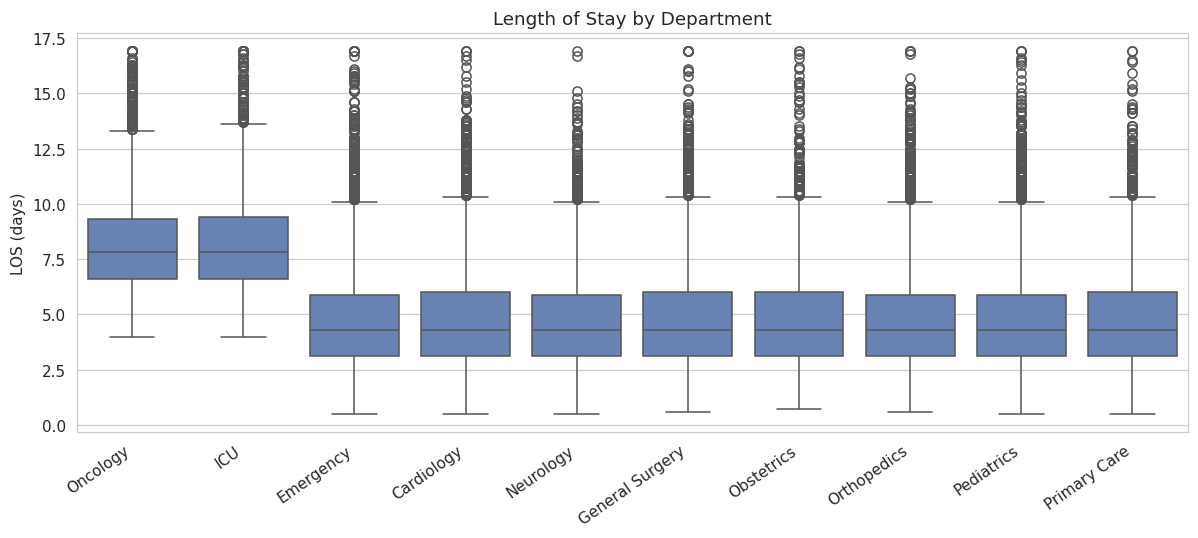

In [3]:
fig, ax = plt.subplots(figsize=(11,5))
order = features.groupby('department')['length_of_stay_days'].median().sort_values(ascending=False).index
sns.boxplot(data=features, x='department', y='length_of_stay_days', order=order, ax=ax, color='#5B7FBF')
ax.set_title('Length of Stay by Department')
ax.set_ylabel('LOS (days)')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('../visuals/02_los_by_department.png')
plt.show()

## Readmission rate by discharge efficiency bucket

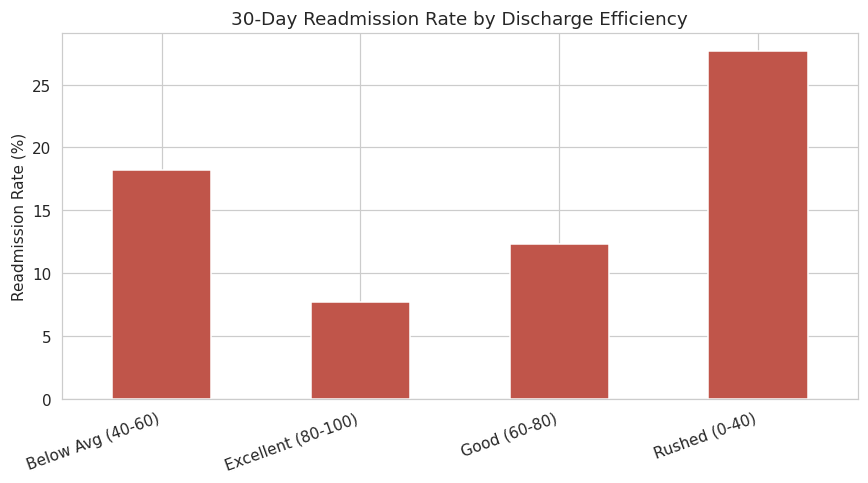

In [4]:
readmit_by_bucket = features.groupby('discharge_efficiency_bucket', observed=True)['readmitted_30d'].mean() * 100
fig, ax = plt.subplots(figsize=(8,4.5))
readmit_by_bucket.plot(kind='bar', ax=ax, color='#C0554A')
ax.set_title('30-Day Readmission Rate by Discharge Efficiency')
ax.set_ylabel('Readmission Rate (%)')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../visuals/03_readmission_by_discharge_efficiency.png')
plt.show()

## Triage wait time vs. patient satisfaction

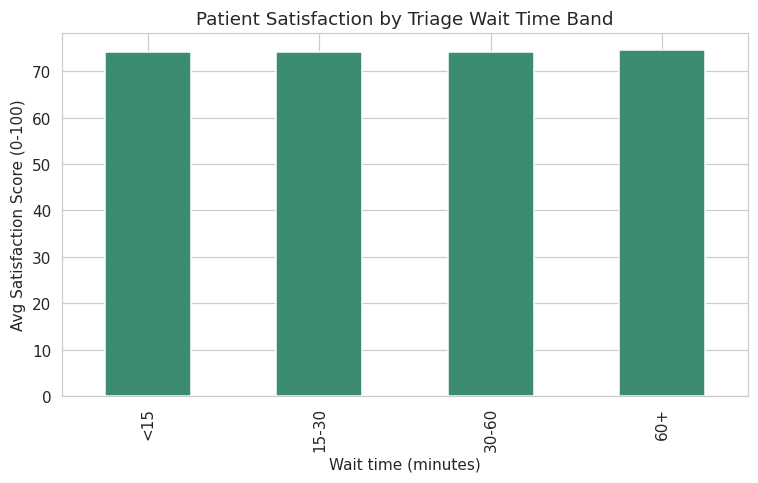

In [5]:
sat = features.dropna(subset=['satisfaction_score']).copy()
sat['wait_band'] = pd.cut(sat.wait_minutes, bins=[0,15,30,60,10000], labels=['<15','15-30','30-60','60+'])
band_sat = sat.groupby('wait_band', observed=True)['satisfaction_score'].mean()

fig, ax = plt.subplots(figsize=(7,4.5))
band_sat.plot(kind='bar', ax=ax, color='#3C8C74')
ax.set_title('Patient Satisfaction by Triage Wait Time Band')
ax.set_ylabel('Avg Satisfaction Score (0-100)')
ax.set_xlabel('Wait time (minutes)')
plt.tight_layout()
plt.savefig('../visuals/04_satisfaction_by_wait_band.png')
plt.show()

## Admission type mix by department (stacked)

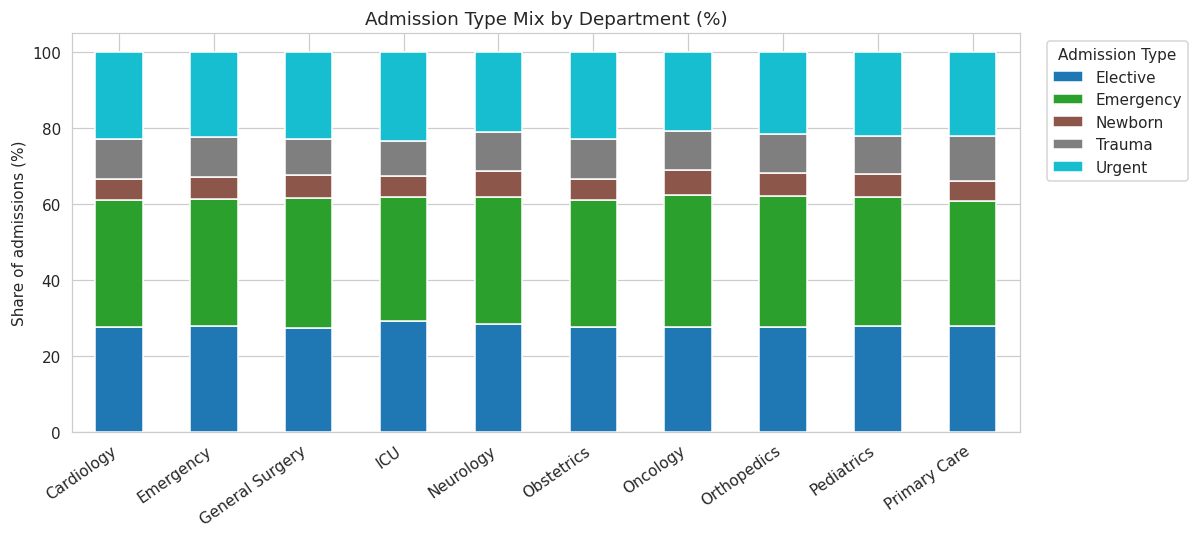

In [6]:
mix = pd.crosstab(features.department, features.admission_type, normalize='index') * 100
fig, ax = plt.subplots(figsize=(11,5))
mix.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
ax.set_title('Admission Type Mix by Department (%)')
ax.set_ylabel('Share of admissions (%)')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', title='Admission Type')
plt.tight_layout()
plt.savefig('../visuals/05_admission_type_mix.png')
plt.show()

## Correlation heatmap of numeric operational fields

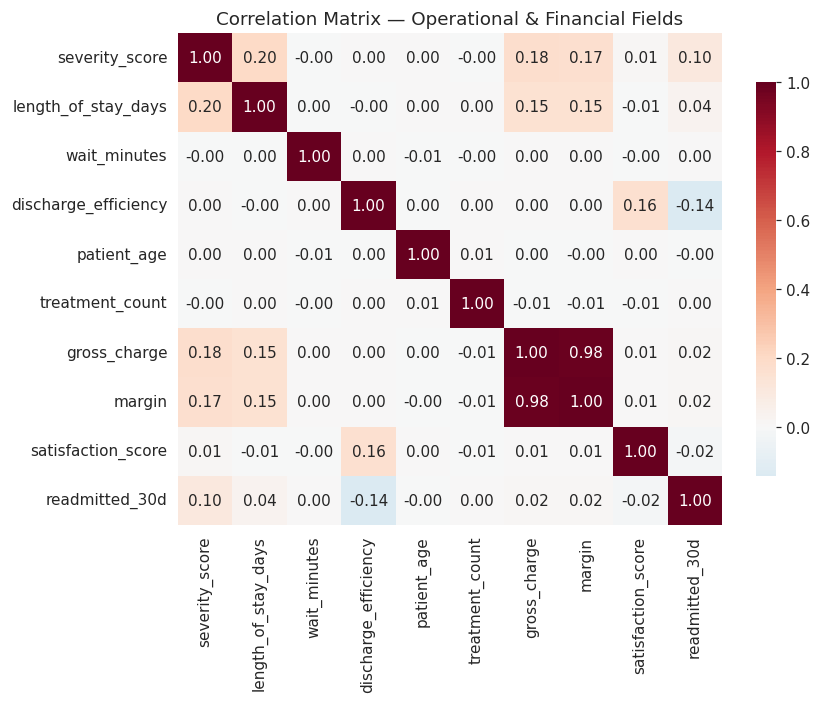

In [7]:
numeric_cols = ['severity_score','length_of_stay_days','wait_minutes','discharge_efficiency',
                 'patient_age','treatment_count','gross_charge','margin','satisfaction_score','readmitted_30d']
corr = features[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8,6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix — Operational & Financial Fields')
plt.tight_layout()
plt.savefig('../visuals/06_correlation_heatmap.png')
plt.show()